# 03 — Exploratory Data Analysis & Visualization

Analyze Reliance price trends, returns, moving averages, volatility, volume and feature relationships.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

files = list(Path("../data").glob("*.csv")) or list(Path("data").glob("*.csv"))
if not files:
    raise FileNotFoundError("Place the Reliance OHLCV CSV in the project's data/ folder.")
df = pd.read_csv(files[0])
df.columns = df.columns.str.strip()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
for c in ["Open","High","Low","Close","Volume"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["Date","Open","High","Low","Close"]).drop_duplicates().sort_values("Date").reset_index(drop=True)
df.head()


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,4456424,1.111319e+14,NaN,NaN,NaN
1,2000-01-04,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,9487878,2.500222e+14,NaN,NaN,NaN
2,2000-01-05,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,26833684,7.373697e+14,NaN,NaN,NaN
3,2000-01-06,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,15682286,4.633254e+14,NaN,NaN,NaN
4,2000-01-07,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,19870977,6.138388e+14,NaN,NaN,NaN


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

df["Return_1D"] = df["Close"].pct_change()
df["SMA_5"] = df["Close"].rolling(5).mean()
df["SMA_20"] = df["Close"].rolling(20).mean()
df["Volatility_20D"] = df["Return_1D"].rolling(20).std()

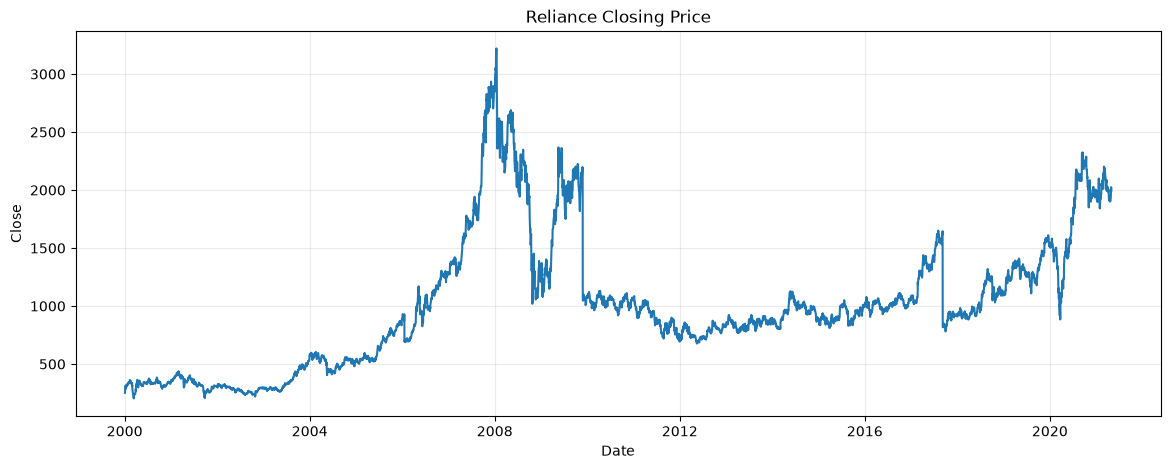

In [3]:
plt.figure(figsize=(14,5))
plt.plot(df["Date"], df["Close"])
plt.title("Reliance Closing Price")
plt.xlabel("Date"); plt.ylabel("Close"); plt.grid(alpha=.25); plt.show()

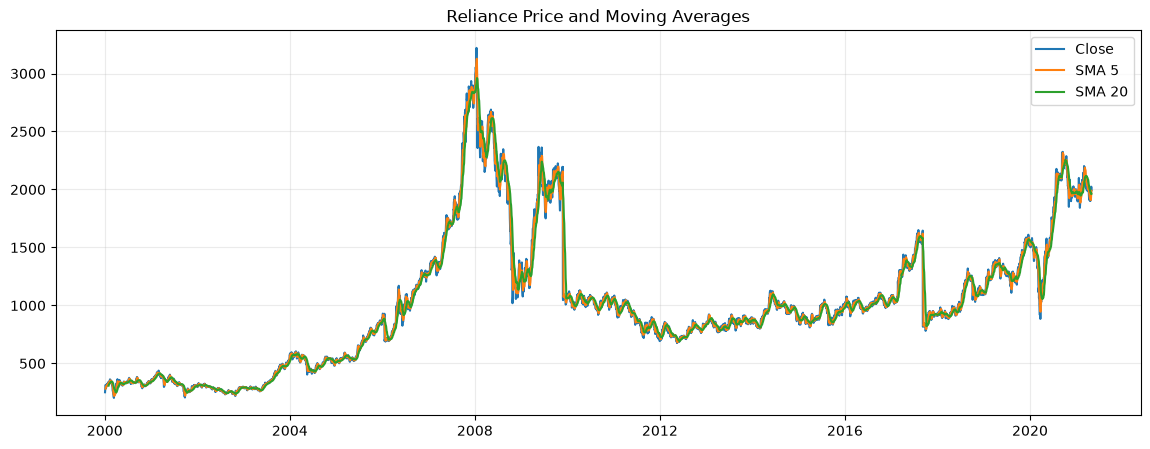

In [4]:
plt.figure(figsize=(14,5))
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["SMA_5"], label="SMA 5")
plt.plot(df["Date"], df["SMA_20"], label="SMA 20")
plt.legend(); plt.title("Reliance Price and Moving Averages"); plt.grid(alpha=.25); plt.show()

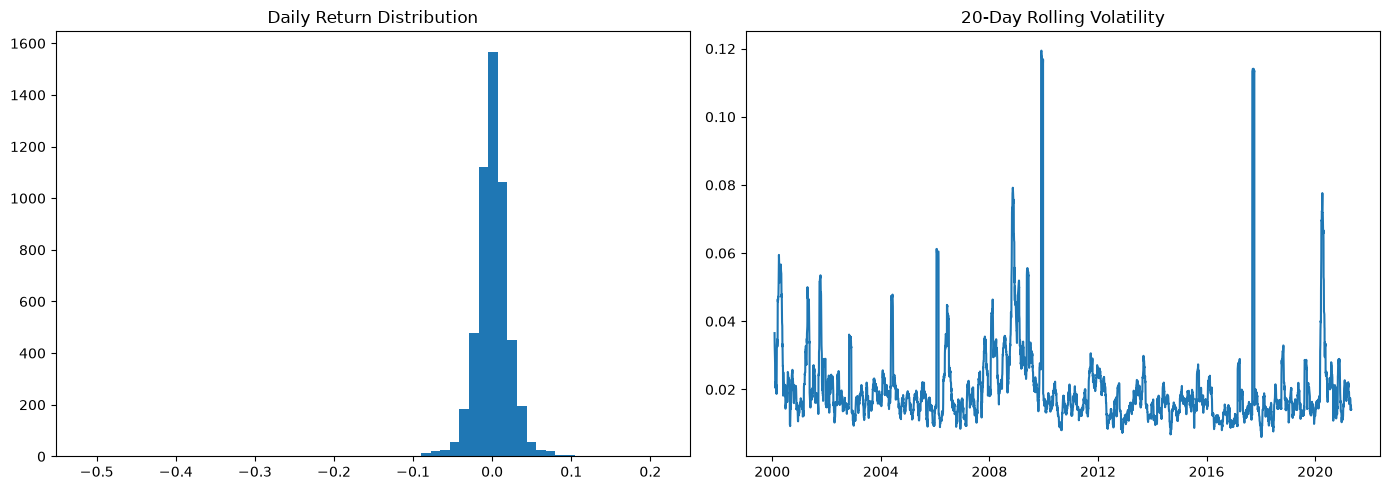

In [5]:
fig, ax = plt.subplots(1,2,figsize=(14,5))
ax[0].hist(df["Return_1D"].dropna(), bins=60)
ax[0].set_title("Daily Return Distribution")
ax[1].plot(df["Date"], df["Volatility_20D"])
ax[1].set_title("20-Day Rolling Volatility")
plt.tight_layout(); plt.show()

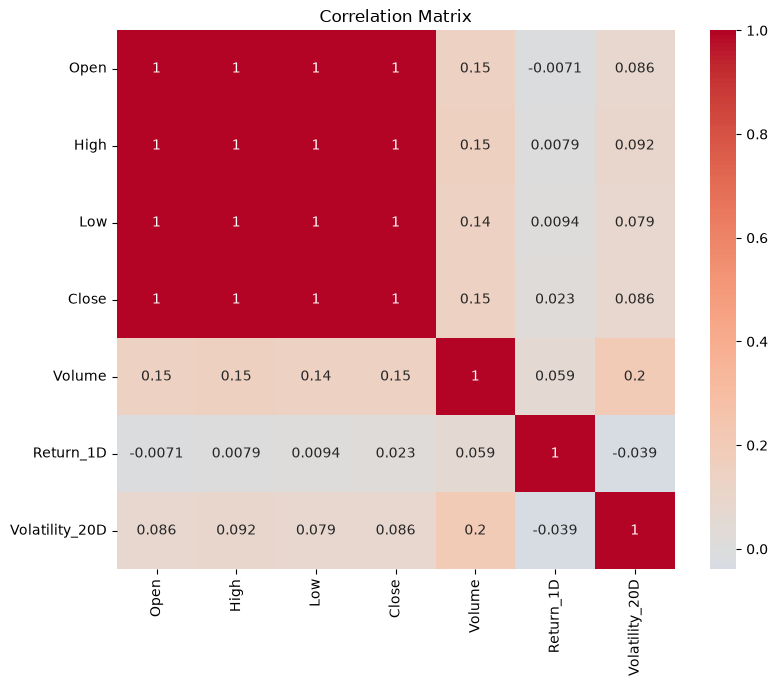

In [6]:
cols=["Open","High","Low","Close","Volume","Return_1D","Volatility_20D"]
plt.figure(figsize=(9,7))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix"); plt.show()